In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

qualitative_dir = Path.cwd()
rubrics_dir = qualitative_dir

# print sys.path
print(rubrics_dir)

/Users/peterkirgis/Documents/hal-paper-analysis/qualitative/results


In [2]:
df = pd.read_csv(rubrics_dir / 'compiled_rubrics.csv')

In [3]:
# strip df['model] to only include after last slash
df['model'] = df['model'].apply(lambda x: x.split('/')[-1])

def standardize_model_name(model_name):
    """
    Standardize model names by removing dates, version numbers, and suffixes.
    
    Examples:
        'claude-3-7-sonnet-20250219' -> 'claude-3-7-sonnet'
        'o4-mini-2025-04-16_high' -> 'o4-mini'
        'gemini-2.0-flash-001' -> 'gemini-2.0-flash'
        'gpt-5-2025-08-07' -> 'gpt-5'
    """
    # Remove date patterns (YYYY-MM-DD or YYYYMMDD)
    name = re.sub(r'-?\d{4}-?\d{2}-?\d{2}', '', model_name)
    
    # Remove version suffixes like -001, -002
    name = re.sub(r'-\d{3}$', '', name)
    
    # Clean up any trailing dashes or underscores
    name = name.strip('-_')
    
    return name

df['model'] = df['model'].apply(standardize_model_name)

# Drop rows with model == gpt-5_minimal
df = df[df['model'] != 'gpt-5_minimal']

# Combine o3 and o3_medium into o3_medium and gpt-5 and gpt-5_high in gpt-5_high
df['model'] = df['model'].replace({
    'o3': 'o3_medium',
    'gpt-5': 'gpt-5_high'
})

In [4]:
# Create composite outcome metric, for benchmark == "assistantbench" task_success = eval_score > 0.7 for scicode eval_has_successful_subtasks = True for all other benchmarks task_success = True if eval_is_successful is True

def compute_outcome(row):
    if row['benchmark_id'] == 'assistantbench':
        return row['eval_score'] > 0.7
    elif row['benchmark_id'] == 'scicode':
        return row['eval_has_successful_subtasks']
    else:
        return row['eval_is_successful']
    
df['task_success'] = df.apply(compute_outcome, axis=1)

In [5]:
df.columns

Index(['benchmark_id', 'rubric', 'model', 'task_id', 'agent_run_id',
       'eval_is_successful', 'label', 'output_explanation.text',
       'docent_message_count', 'eval_has_successful_subtasks', 'eval_answer',
       'eval_score', 'task_success'],
      dtype='object')

In [6]:
# drop duplicates based on benchmark_id, task_id, model, keeping the first
task_length_df = df.drop_duplicates(subset=['benchmark_id', 'task_id', 'model'], keep='first')

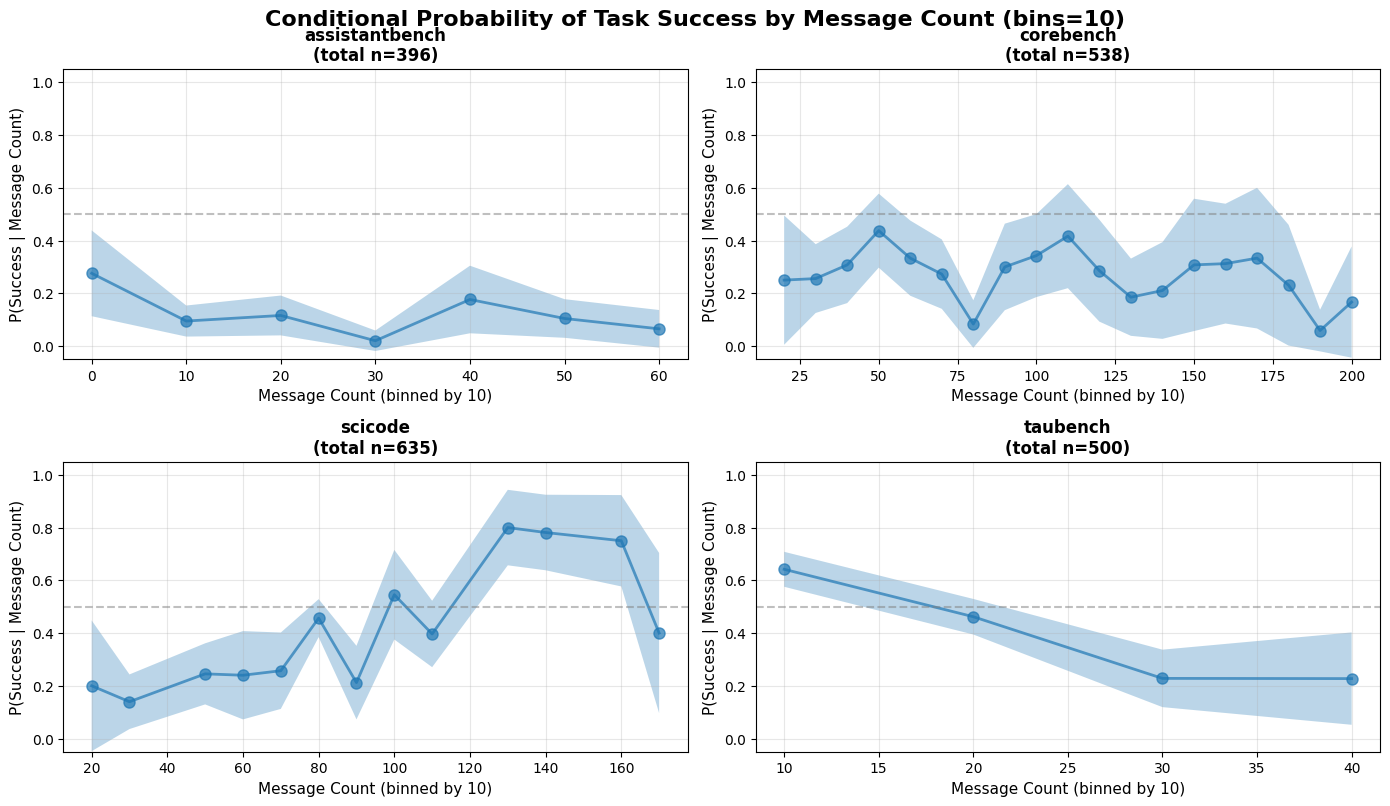

In [8]:
# If you want to bin the message counts to get smoother curves:
def plot_success_by_message_count_panel_binned(df, bin_size=5, min_samples=5):
    """
    Create panel plots with binned message counts for smoother curves.
    """
    
    # Create message count bins
    df = df.copy()
    df['message_bin'] = (df['docent_message_count'] // bin_size) * bin_size
    
    benchmarks = sorted(df['benchmark_id'].unique())
    n_benchmarks = len(benchmarks)
    ncols = 2
    nrows = int(np.ceil(n_benchmarks / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows), squeeze=False)
    axes = axes.flatten()
    
    for idx, benchmark in enumerate(benchmarks):
        ax = axes[idx]
        bench_df = df[df['benchmark_id'] == benchmark].copy()
        
        # Group by binned message count
        grouped = bench_df.groupby('message_bin').agg({
            'task_success': ['sum', 'count', 'mean']
        }).reset_index()
        
        grouped.columns = ['message_bin', 'successes', 'total', 'prob_success']
        grouped = grouped[grouped['total'] >= min_samples]
        
        if len(grouped) == 0:
            ax.text(0.5, 0.5, 'Insufficient data', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{benchmark}\n(n=0)")
            continue
        
        # Plot with shaded error bars (confidence intervals)
        # Simple approximation: standard error
        grouped['se'] = np.sqrt(grouped['prob_success'] * (1 - grouped['prob_success']) / grouped['total'])
        
        ax.plot(grouped['message_bin'], grouped['prob_success'], 
               marker='o', linewidth=2, markersize=8, alpha=0.7, label='P(Success)')
        ax.fill_between(grouped['message_bin'], 
                        grouped['prob_success'] - 1.96*grouped['se'],
                        grouped['prob_success'] + 1.96*grouped['se'],
                        alpha=0.3)
        
        ax.set_xlabel(f'Message Count (binned by {bin_size})', fontsize=11)
        ax.set_ylabel('P(Success | Message Count)', fontsize=11)
        ax.set_title(f"{benchmark}\n(total n={len(bench_df)})", fontsize=12, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    
    for idx in range(n_benchmarks, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'Conditional Probability of Task Success by Message Count (bins={bin_size})', 
                fontsize=16, fontweight='bold', y=1.002)
    
    return fig


# Usage with binning:
fig = plot_success_by_message_count_panel_binned(task_length_df, bin_size=10, min_samples=10)
plt.show()

In [62]:
def within_task_correlation_analysis(df):
    """
    Compute correlation between message count and success for each task.
    Only includes tasks with variation in both message count and outcomes.
    """
    
    results = []
    
    for (benchmark, task_id), task_df in df.groupby(['benchmark_id', 'task_id']):
        # Need variation in both variables
        if task_df['task_success'].nunique() < 2:
            continue  # No variation in success
        if task_df['docent_message_count'].nunique() < 2:
            continue  # No variation in message count
        if len(task_df) < 5:
            continue  # Too few samples
        
        # Compute point-biserial correlation (continuous vs binary)
        corr, pval = stats.pointbiserialr(
            task_df['docent_message_count'], 
            task_df['task_success']
        )
        
        results.append({
            'benchmark_id': benchmark,
            'task_id': task_id,
            'correlation': corr,
            'p_value': pval,
            'n_runs': len(task_df),
            'success_rate': task_df['task_success'].mean(),
            'mean_messages': task_df['docent_message_count'].mean(),
            'std_messages': task_df['docent_message_count'].std()
        })
    
    results_df = pd.DataFrame(results)
    
    return results_df


# Run analysis
correlation_results = within_task_correlation_analysis(task_length_df)

# Summary statistics
print("Within-Task Correlation Analysis")
print("=" * 60)
print(f"Total tasks analyzed: {len(correlation_results)}")
print(f"Positive correlations: {(correlation_results['correlation'] > 0).sum()}")
print(f"Negative correlations: {(correlation_results['correlation'] < 0).sum()}")
print(f"Significant (p<0.05): {(correlation_results['p_value'] < 0.05).sum()}")
print(f"\nMean correlation: {correlation_results['correlation'].mean():.3f}")
print(f"Median correlation: {correlation_results['correlation'].median():.3f}")

# By benchmark
print("\nBy Benchmark:")
for benchmark in correlation_results['benchmark_id'].unique():
    bench_corr = correlation_results[correlation_results['benchmark_id'] == benchmark]
    print(f"  {benchmark}:")
    print(f"    Mean correlation: {bench_corr['correlation'].mean():.3f}")
    print(f"    Significant tasks: {(bench_corr['p_value'] < 0.05).sum()}/{len(bench_corr)}")



Within-Task Correlation Analysis
Total tasks analyzed: 131
Positive correlations: 67
Negative correlations: 64
Significant (p<0.05): 11

Mean correlation: -0.017
Median correlation: 0.015

By Benchmark:
  assistantbench:
    Mean correlation: 0.018
    Significant tasks: 2/20
  corebench:
    Mean correlation: -0.063
    Significant tasks: 2/30
  scicode:
    Mean correlation: 0.090
    Significant tasks: 4/44
  taubench:
    Mean correlation: -0.127
    Significant tasks: 3/37


In [70]:
def compute_model_efficiency(df, quantiles=[0.25, 0.5, 0.75]):
    """
    For each model, compute success rate at different message count quantiles.
    This controls for task difficulty by looking at relative message counts.
    """
    
    results = []
    
    for model in df['model'].unique():
        model_df = df[df['model'] == model].copy()
        
        # Overall stats
        overall_success = model_df['task_success'].mean()
        mean_messages = model_df['docent_message_count'].mean()
        
        # Compute quantile thresholds for this model
        quantile_values = model_df['docent_message_count'].quantile(quantiles)
        
        for q, threshold in zip(quantiles, quantile_values):
            # Success rate at or below this quantile
            low_msg = model_df[model_df['docent_message_count'] <= threshold]
            success_at_quantile = low_msg['task_success'].mean() if len(low_msg) > 0 else np.nan
            
            results.append({
                'model': model,
                'quantile': q,
                'message_threshold': threshold,
                'success_rate': success_at_quantile,
                'n_runs': len(low_msg),
                'overall_success': overall_success,
                'mean_messages': mean_messages
            })
    
    return pd.DataFrame(results)


def compute_model_efficiency_simple(df):
    """
    Simple approach: For each model, compute success rate in bottom 25% vs top 25% of message counts.
    High efficiency = high success rate with low message counts.
    """
    
    results = []
    
    for model in df['model'].unique():
        model_df = df[df['model'] == model].copy()
        
        if len(model_df) < 10:  # Skip models with too few runs
            continue
        
        # Get quartile thresholds
        q25 = model_df['docent_message_count'].quantile(0.25)
        q75 = model_df['docent_message_count'].quantile(0.75)
        
        # Split into low and high message count groups
        low_msg = model_df[model_df['docent_message_count'] <= q25]
        high_msg = model_df[model_df['docent_message_count'] >= q75]
        
        # Compute success rates
        low_success = low_msg['task_success'].mean()
        high_success = high_msg['task_success'].mean()
        
        # Efficiency score: success in low messages relative to high messages
        # Positive = more efficient (maintains success with fewer messages)
        efficiency = low_success - high_success
        
        results.append({
            'model': model,
            'low_message_success': low_success,
            'high_message_success': high_success,
            'efficiency_score': efficiency,
            'low_n': len(low_msg),
            'high_n': len(high_msg),
            'overall_success': model_df['task_success'].mean(),
            'mean_messages': model_df['docent_message_count'].mean(),
            'median_messages': model_df['docent_message_count'].median()
        })
    
    return pd.DataFrame(results).sort_values('efficiency_score', ascending=False)


# Run the analysis
efficiency_df = compute_model_efficiency_simple(task_length_df)

print("Model Efficiency Analysis")
print("=" * 80)
print("Efficiency Score = Success Rate (Low Messages) - Success Rate (High Messages)")
print("Positive score = More efficient (maintains success with fewer messages)")
print("=" * 80)
print(efficiency_df.to_string(index=False))

Model Efficiency Analysis
Efficiency Score = Success Rate (Low Messages) - Success Rate (High Messages)
Positive score = More efficient (maintains success with fewer messages)
                 model  low_message_success  high_message_success  efficiency_score  low_n  high_n  overall_success  mean_messages  median_messages
  claude-opus-4.1_high             0.676471              0.406250          0.270221     34      32         0.406250      65.851562             49.0
      gemini-2.0-flash             0.346939              0.145833          0.201105     49      48         0.273684      91.389474             67.5
             o3_medium             0.500000              0.361702          0.138298     50      47         0.417112      69.000000             57.0
           DeepSeek-V3             0.254902              0.127660          0.127242     51      47         0.139037      61.491979             52.0
               gpt-4.1             0.551020              0.479167          0.071854 

In [77]:
df.columns

Index(['benchmark_id', 'rubric', 'model', 'task_id', 'agent_run_id',
       'eval_is_successful', 'label', 'output_explanation.text',
       'docent_message_count', 'eval_has_successful_subtasks', 'eval_answer',
       'eval_score', 'task_success'],
      dtype='object')

In [83]:
# convert rubric to columns based on label
label_df = df[['benchmark_id', 'task_id', 'model', 'docent_message_count', 'task_success', 'rubric', 'label']].copy()

# replace label with True if "match" else false
label_df['label'] = label_df['label'].apply(lambda x: True if x == "match" else False)

df_label_pivot = label_df.pivot_table(index=['benchmark_id', 'task_id', 'model', 'docent_message_count', 'task_success'],
                                      columns='rubric',
                                      values='label',
                                      fill_value=False).reset_index()



In [ ]:
df_label_pivot.columns

In [9]:
def compute_task_residuals(df, benchmark_id=None):
    """
    Compute task-residualized values for message count and success rate.
    
    For each task:
    1. Calculate expected message count (mean across models)
    2. Calculate expected success rate (mean across models)
    3. Compute residuals: actual - expected
    
    This controls for task difficulty by comparing each model's performance
    to the task baseline.
    
    Args:
        df: DataFrame with columns ['benchmark_id', 'task_id', 'model', 
            'docent_message_count', 'task_success']
        benchmark_id: If provided, filter to single benchmark
        
    Returns:
        DataFrame with original columns plus:
        - expected_messages: task-level mean message count
        - expected_success: task-level mean success rate
        - residual_messages: actual - expected messages
        - residual_success: actual - expected success
    """
    
    # Filter to benchmark if specified
    if benchmark_id is not None:
        df = df[df['benchmark_id'] == benchmark_id].copy()
    else:
        df = df.copy()
    
    # Compute task-level baselines (expected values)
    task_baselines = df.groupby(['benchmark_id', 'task_id']).agg({
        'docent_message_count': 'mean',
        'task_success': 'mean'
    }).reset_index()
    
    task_baselines.columns = ['benchmark_id', 'task_id', 'expected_messages', 'expected_success']
    
    # Merge baselines back to original data
    df_with_residuals = df.merge(task_baselines, on=['benchmark_id', 'task_id'], how='left')
    
    # Compute residuals
    df_with_residuals['residual_messages'] = (
        df_with_residuals['docent_message_count'] - df_with_residuals['expected_messages']
    )
    df_with_residuals['residual_success'] = (
        df_with_residuals['task_success'] - df_with_residuals['expected_success']
    )
    
    return df_with_residuals


def plot_task_residualized_message_effect(df, benchmark_id=None, bin_size=10, min_samples=5):
    """
    Plot marginal effect of message count on task success, controlling for task difficulty.
    
    Creates scatter plot of residual messages vs residual success with binned curve.
    
    Args:
        df: DataFrame with task data
        benchmark_id: If provided, create single plot for that benchmark.
                     If None, create panel plot for all benchmarks.
        bin_size: Width of bins for smoothing curve
        min_samples: Minimum samples per bin to include
        
    Returns:
        matplotlib Figure
    """
    
    # Compute residuals
    residuals_df = compute_task_residuals(df, benchmark_id=benchmark_id)
    
    if benchmark_id is not None:
        # Single plot
        fig, ax = plt.subplots(figsize=(10, 6))
        _plot_single_residual_panel(residuals_df, ax, benchmark_id, bin_size, min_samples)
        plt.tight_layout()
    else:
        # Panel plot for all benchmarks
        benchmarks = sorted(residuals_df['benchmark_id'].unique())
        n_benchmarks = len(benchmarks)
        ncols = 2
        nrows = int(np.ceil(n_benchmarks / ncols))
        
        fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows), squeeze=False)
        axes = axes.flatten()
        
        for idx, bench in enumerate(benchmarks):
            ax = axes[idx]
            bench_df = residuals_df[residuals_df['benchmark_id'] == bench]
            _plot_single_residual_panel(bench_df, ax, bench, bin_size, min_samples)
        
        # Turn off unused axes
        for idx in range(n_benchmarks, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        fig.suptitle('Task-Residualized Message Effect on Success (Controlling for Task Difficulty)', 
                    fontsize=16, fontweight='bold', y=1.002)
    
    return fig


def _plot_single_residual_panel(bench_df, ax, benchmark_name, bin_size, min_samples):
    """
    Helper function to plot a single residual panel.
    """
    
    if len(bench_df) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{benchmark_name}\n(n=0)")
        return
    
    # Scatter plot of individual points
    ax.scatter(bench_df['residual_messages'], 
              bench_df['residual_success'],
              alpha=0.4, s=30, color='steelblue', edgecolor='none')
    
    # Create bins for smoothing
    bench_df = bench_df.copy()
    bench_df['message_bin'] = (bench_df['residual_messages'] // bin_size) * bin_size
    
    # Group by bin
    grouped = bench_df.groupby('message_bin').agg({
        'residual_success': ['mean', 'std', 'count']
    }).reset_index()
    
    grouped.columns = ['message_bin', 'mean_success', 'std_success', 'count']
    grouped = grouped[grouped['count'] >= min_samples]
    
    if len(grouped) > 0:
        # Plot binned curve with confidence intervals
        grouped['se'] = grouped['std_success'] / np.sqrt(grouped['count'])
        grouped['ci'] = 1.96 * grouped['se']
        
        ax.plot(grouped['message_bin'], grouped['mean_success'],
               color='red', linewidth=2.5, marker='o', markersize=8,
               label='Binned mean', zorder=5)
        
        ax.fill_between(grouped['message_bin'],
                       grouped['mean_success'] - grouped['ci'],
                       grouped['mean_success'] + grouped['ci'],
                       color='red', alpha=0.2, zorder=4)
    
    # Add reference lines
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    # Compute correlation
    corr, pval = stats.pearsonr(bench_df['residual_messages'], bench_df['residual_success'])
    
    # Labels and title
    ax.set_xlabel('Residual Message Count\n(Actual - Expected)', fontsize=11)
    ax.set_ylabel('Residual Success\n(Actual - Expected)', fontsize=11)
    ax.set_title(f"{benchmark_name}\n(n={len(bench_df)}, r={corr:.3f}, p={pval:.3f})", 
                fontsize=12, fontweight='bold')
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    
    # Set reasonable limits
    x_max = max(abs(bench_df['residual_messages'].min()), abs(bench_df['residual_messages'].max()))
    y_max = max(abs(bench_df['residual_success'].min()), abs(bench_df['residual_success'].max()))
    
    if x_max > 0:
        ax.set_xlim(-x_max * 1.1, x_max * 1.1)
    if y_max > 0:
        ax.set_ylim(-y_max * 1.1, y_max * 1.1)

Message Count Distributions by Benchmark


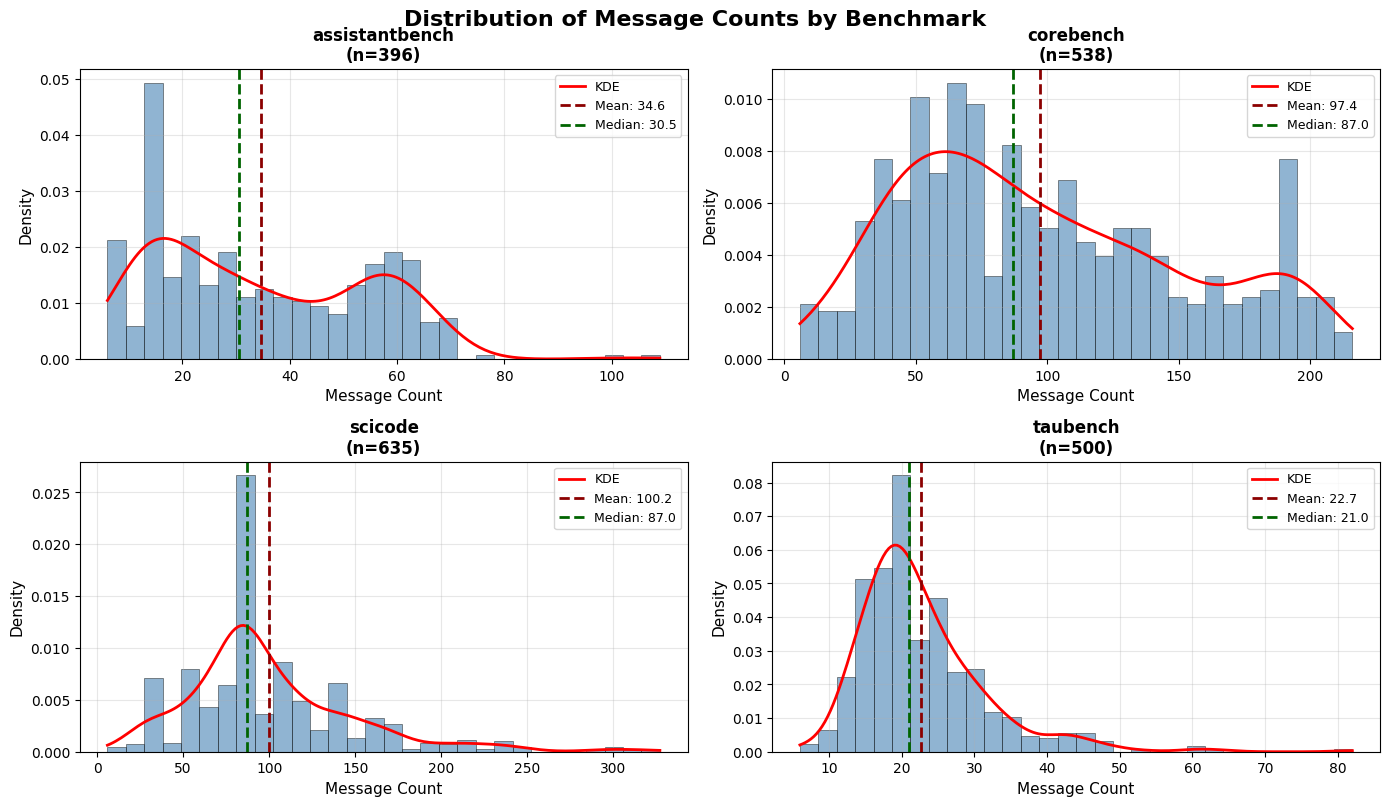

In [11]:
def plot_message_count_distributions(df):
    """
    Plot probability density functions of message counts for each benchmark.
    
    Args:
        df: DataFrame with columns ['benchmark_id', 'docent_message_count']
        
    Returns:
        matplotlib Figure
    """
    benchmarks = sorted(df['benchmark_id'].unique())
    n_benchmarks = len(benchmarks)
    ncols = 2
    nrows = int(np.ceil(n_benchmarks / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows), squeeze=False)
    axes = axes.flatten()
    
    for idx, benchmark in enumerate(benchmarks):
        ax = axes[idx]
        bench_df = df[df['benchmark_id'] == benchmark]
        
        if len(bench_df) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{benchmark}\n(n=0)")
            continue
        
        # Plot histogram with density
        ax.hist(bench_df['docent_message_count'], bins=30, density=True, 
               alpha=0.6, color='steelblue', edgecolor='black', linewidth=0.5)
        
        # Plot KDE (kernel density estimate) for smooth curve
        try:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(bench_df['docent_message_count'])
            x_range = np.linspace(bench_df['docent_message_count'].min(), 
                                 bench_df['docent_message_count'].max(), 200)
            ax.plot(x_range, kde(x_range), color='red', linewidth=2, label='KDE')
        except:
            pass  # Skip KDE if it fails
        
        # Add statistics
        mean_val = bench_df['docent_message_count'].mean()
        median_val = bench_df['docent_message_count'].median()
        
        ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2, 
                  label=f'Mean: {mean_val:.1f}')
        ax.axvline(median_val, color='darkgreen', linestyle='--', linewidth=2, 
                  label=f'Median: {median_val:.1f}')
        
        ax.set_xlabel('Message Count', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f"{benchmark}\n(n={len(bench_df)})", 
                    fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    # Turn off unused axes
    for idx in range(n_benchmarks, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    fig.suptitle('Distribution of Message Counts by Benchmark', 
                fontsize=16, fontweight='bold', y=1.002)
    
    return fig


# Plot message count distributions
print("Message Count Distributions by Benchmark")
print("=" * 60)

fig = plot_message_count_distributions(task_length_df)
plt.show()

Computing task-residualized message effects...


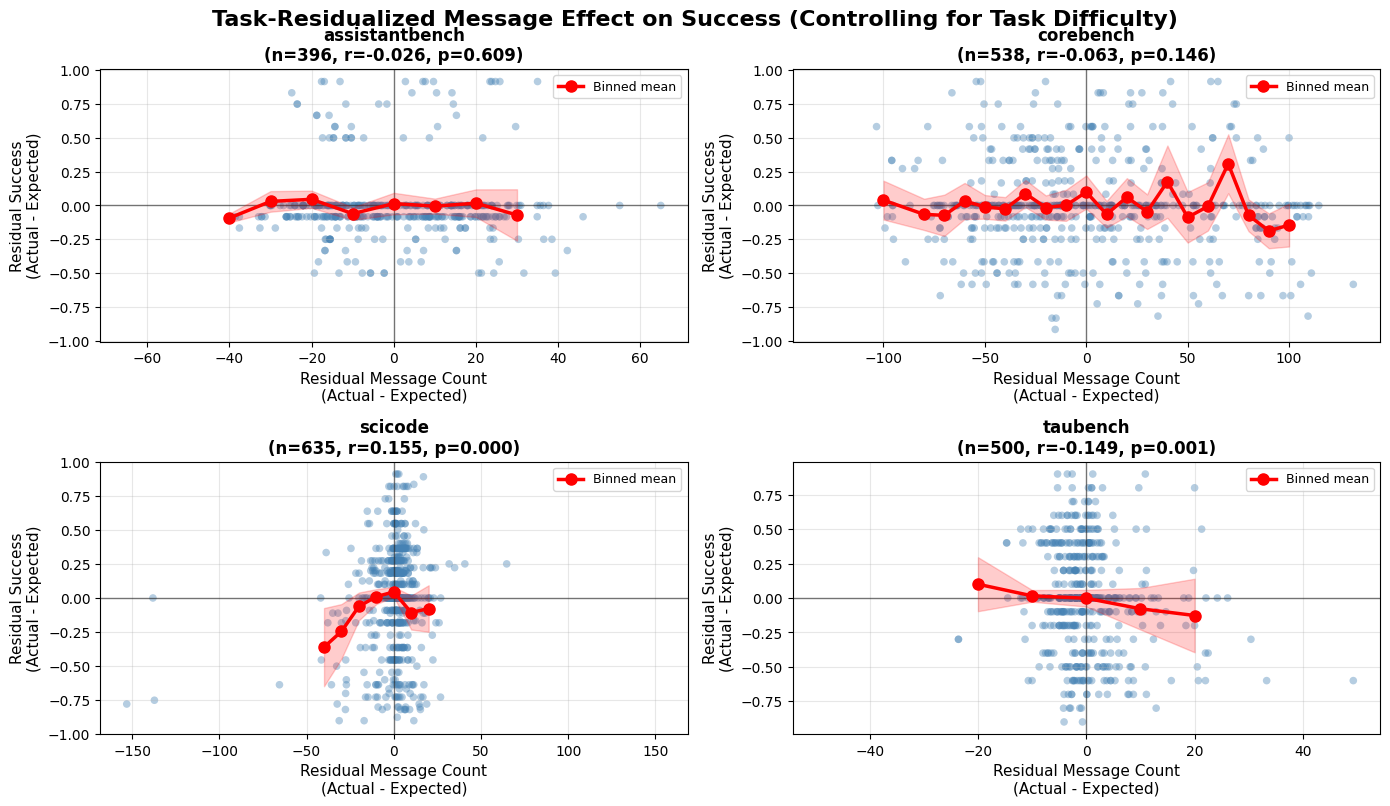


Interpretation:
------------------------------------------------------------
Positive correlation: More messages help (after controlling for difficulty)
Negative correlation: More messages indicate struggle
Near-zero correlation: No marginal effect

Note: By residualizing, we control for task difficulty.
Each point shows deviation from task-level baseline.


In [10]:
# Run the task-residualized analysis
print("Computing task-residualized message effects...")
print("=" * 60)

fig = plot_task_residualized_message_effect(task_length_df, benchmark_id=None, bin_size=10, min_samples=5)
plt.show()

print("\nInterpretation:")
print("-" * 60)
print("Positive correlation: More messages help (after controlling for difficulty)")
print("Negative correlation: More messages indicate struggle")
print("Near-zero correlation: No marginal effect")
print("\nNote: By residualizing, we control for task difficulty.")
print("Each point shows deviation from task-level baseline.")